# Monthly vs yearly

This notebook compares **hindfoot length** and **weight** when the data are grouped by month versus by year.

The visual goal is to see how much detail is visible in monthly averages compared to the smoother yearly averages. The notebook first studies the full dataset, then repeats the same view for the **Dipodomys** genus because it has many observations.

## Load the data

This cell reads the merged dataset into pandas.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../output/merged_full.csv")
df.head()

,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


## Prepare a simple dataset

This cell keeps only the time columns, taxonomy columns, and the two measurement columns we are analyzing.

In [22]:
time_df = df[['year', 'month', 'genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    time_df[col] = time_df[col].astype('string').str.strip()

time_df = time_df.dropna(subset=['year', 'month', 'genus', 'species_name']).copy()
time_df = time_df.loc[time_df['month'].between(1, 12)& time_df['genus'].ne('')& time_df['species_name'].ne('')].copy()

time_df['year'] = time_df['year'].astype(int)
time_df['month'] = time_df['month'].astype(int)
time_df

,year,month,genus,species_name,hindfoot_length,weight
0,1977,8,Dipodomys,merriami,35.0,40.0
1,1977,8,Dipodomys,merriami,37.0,48.0
2,1977,8,Dipodomys,merriami,34.0,29.0
3,1977,8,Dipodomys,merriami,35.0,46.0
4,1977,8,Dipodomys,merriami,35.0,36.0
...,...,...,...,...,...,...
70912,2025,12,Dipodomys,merriami,36.0,47.0
70913,2025,12,Chaetodipus,penicillatus,20.0,16.0
70914,2025,12,Chaetodipus,penicillatus,19.0,14.0
70915,2025,12,Dipodomys,merriami,36.0,42.0


## Build Monthly Summaries

This cell calculates monthly mean hindfoot length and monthly mean weight for the entire dataset. Each row represents one month in one year.

In [23]:
monthly_df = (
    time_df.groupby(['year', 'month'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)

monthly_df['date'] = pd.to_datetime(
    dict(year=monthly_df['year'], month=monthly_df['month'], day=1)
)

monthly_df

,year,month,mean_hindfoot_length,mean_weight,n_observations,date
0,1977,8,31.375000,33.775000,40,1977-08-01
1,1977,9,32.739130,38.195652,46,1977-09-01
2,1977,10,34.883333,39.883333,60,1977-10-01
3,1977,11,36.833333,56.907407,54,1977-11-01
4,1977,12,37.555556,60.203704,54,1977-12-01
...,...,...,...,...,...,...
511,2025,8,24.388889,24.388889,18,2025-08-01
512,2025,9,27.130435,28.217391,23,2025-09-01
513,2025,10,30.200000,35.700000,20,2025-10-01
514,2025,11,24.458333,23.583333,24,2025-11-01


## Build Yearly Summaries

This cell calculates yearly mean hindfoot length and yearly mean weight for the entire dataset. These yearly averages will be overlaid as line plots on top of the monthly scatter plots.

In [28]:
yearly_df = (
    time_df.groupby(['year'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)

yearly_df['date'] = pd.to_datetime(
    dict(year=yearly_df['year'], month=7, day=1)
)

yearly_df.head(10)

,year,mean_hindfoot_length,mean_weight,n_observations,date
0,1977,34.925197,46.555118,254,1977-07-01
1,1978,37.567775,62.854220,782,1978-07-01
2,1979,35.362345,59.204263,563,1979-07-01
3,1980,35.158361,59.588040,903,1980-07-01
4,1981,35.668037,59.871531,973,1981-07-01
5,1982,31.665981,46.872428,1458,1982-07-01
6,1983,32.351444,48.229711,1454,1983-07-01
7,1984,31.877928,42.986436,811,1984-07-01
8,1985,32.600156,43.121283,1278,1985-07-01
9,1986,33.119898,47.515306,784,1986-07-01


## Monthly vs Yearly Visualizations

The plots below compare monthly aggregation against yearly aggregation for the full dataset. Monthly averages are shown as scatter points, while yearly averages are shown as an overlaid line. This keeps the plot focused on the difference between detailed monthly movement and smoother yearly trends.

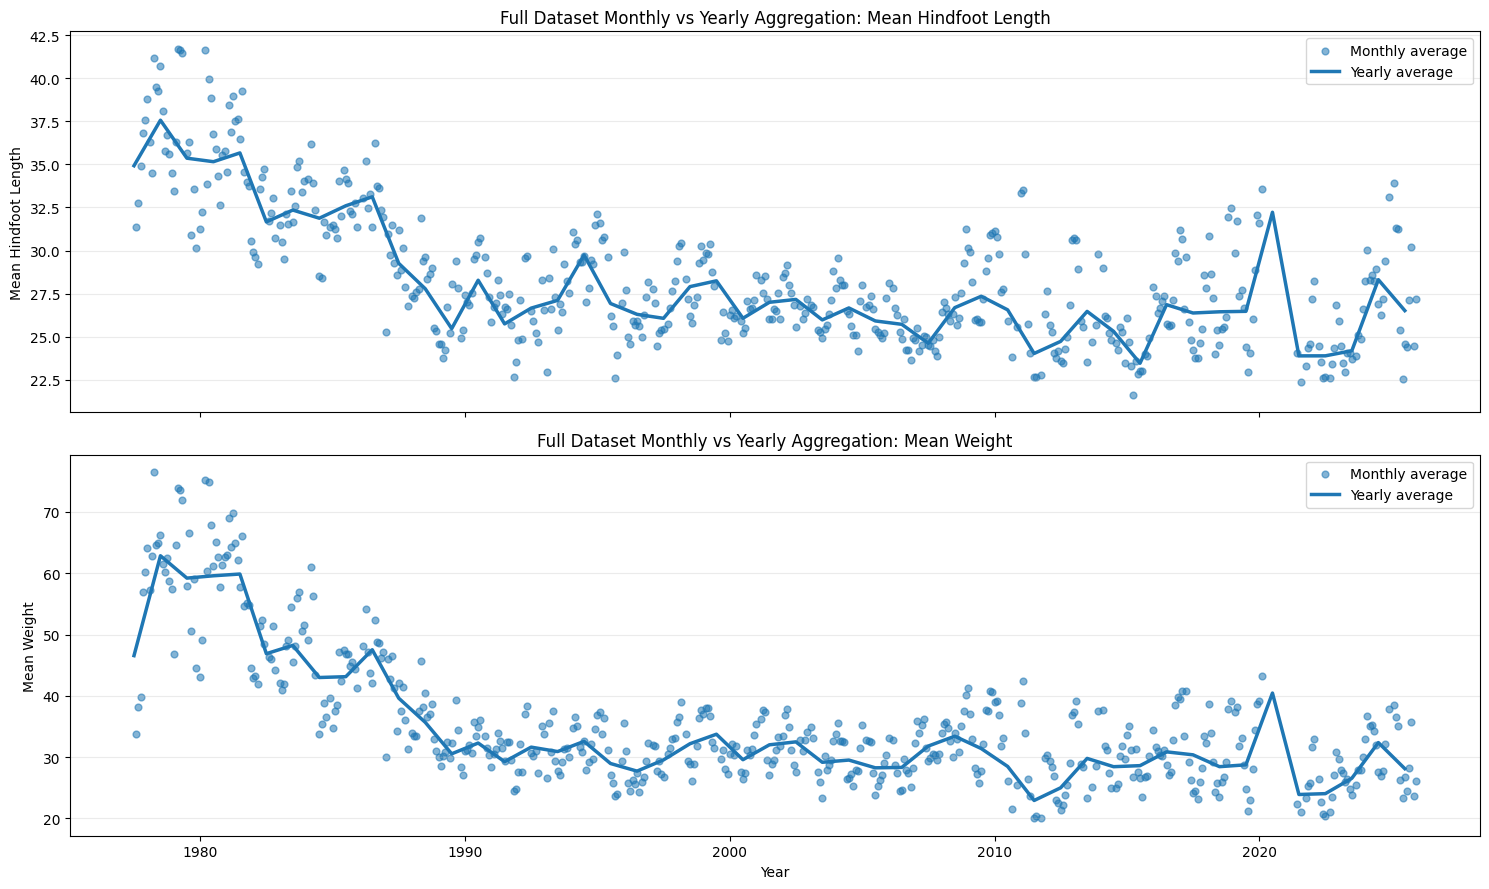

In [ ]:
# FIG 2.1

def plot_monthly_scatter_with_yearly_line(monthly_data, yearly_data, title_prefix):
    metrics = [
        ('mean_hindfoot_length', 'Mean Hindfoot Length'),
        ('mean_weight', 'Mean Weight'),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

    for ax, (metric, ylabel) in zip(axes, metrics):
        clean_monthly = monthly_data.dropna(subset=[metric]).sort_values('date')
        clean_yearly = yearly_data.dropna(subset=[metric]).sort_values('date')

        ax.scatter(
            clean_monthly['date'],
            clean_monthly[metric],
            s=24,
            alpha=0.55,
            label='Monthly average'
        )
        ax.plot(
            clean_yearly['date'],
            clean_yearly[metric],
            linewidth=2.5,
            label='Yearly average'
        )

        ax.set_title(f'{title_prefix}: {ylabel}')
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25)
        ax.legend()

    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.show()

plot_monthly_scatter_with_yearly_line(
    monthly_df,
    yearly_df,
    'Full Dataset Monthly vs Yearly Aggregation'
)

The full-dataset plot shows the overall relationship between month-level and year-level aggregation. The monthly points reveal short-term variation, while the yearly line shows the broader trend after those month-to-month changes are smoothed together.

## Dipodomys Monthly vs Yearly View

The same visualization is repeated for **Dipodomys** only. This genus has many observations, so it is a useful focused example for comparing monthly and yearly aggregation without splitting the chart into every genus.

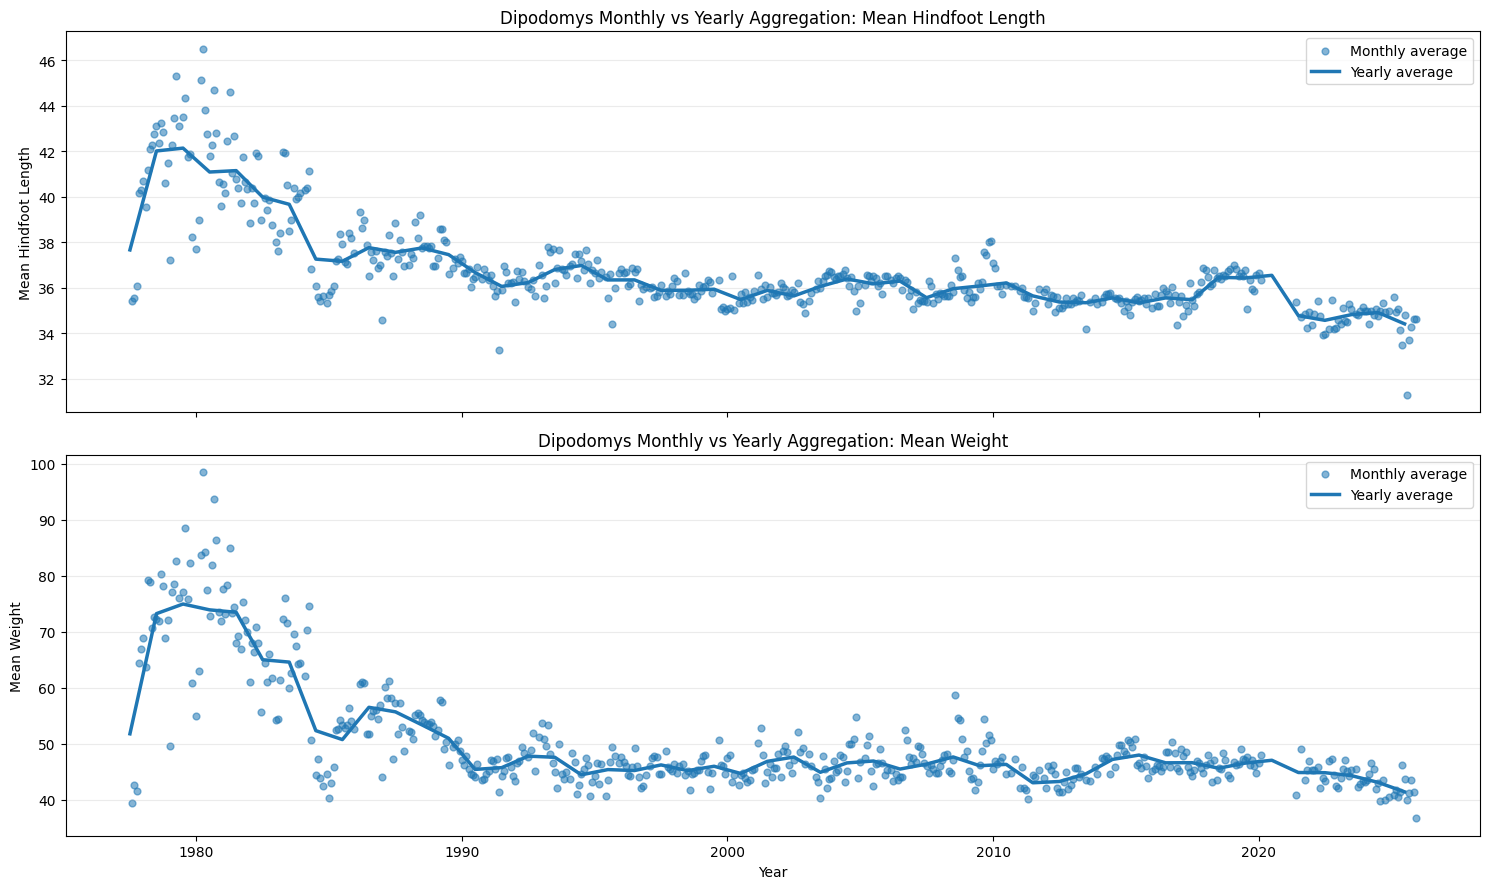

In [ ]:
# FIG 2.2

dipodomys_df = time_df.loc[time_df['genus'] == 'Dipodomys'].copy()

dipodomys_monthly_df = (
    dipodomys_df.groupby(['year', 'month'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)

dipodomys_monthly_df['date'] = pd.to_datetime(
    dict(year=dipodomys_monthly_df['year'], month=dipodomys_monthly_df['month'], day=1)
)

dipodomys_yearly_df = (
    dipodomys_df.groupby(['year'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)

dipodomys_yearly_df['date'] = pd.to_datetime(
    dict(year=dipodomys_yearly_df['year'], month=7, day=1)
)

plot_monthly_scatter_with_yearly_line(
    dipodomys_monthly_df,
    dipodomys_yearly_df,
    'Dipodomys Monthly vs Yearly Aggregation'
)

In the Dipodomys plot, the yearly line gives a cleaner long-term trend, while the monthly points show the spread around that trend. This makes it easier to decide whether yearly aggregation is detailed enough for the question being asked, or whether the monthly values tell a different story.

## Dipodomys Weight by Month Within Each Year

The next plot focuses only on **mean weight** for Dipodomys. Hindfoot length is not included here because it is a body-size measurement that should not change as much within a single calendar year. Weight is more likely to respond to short-term conditions, so it is the better measurement for checking whether monthly patterns repeat across years or look more random.

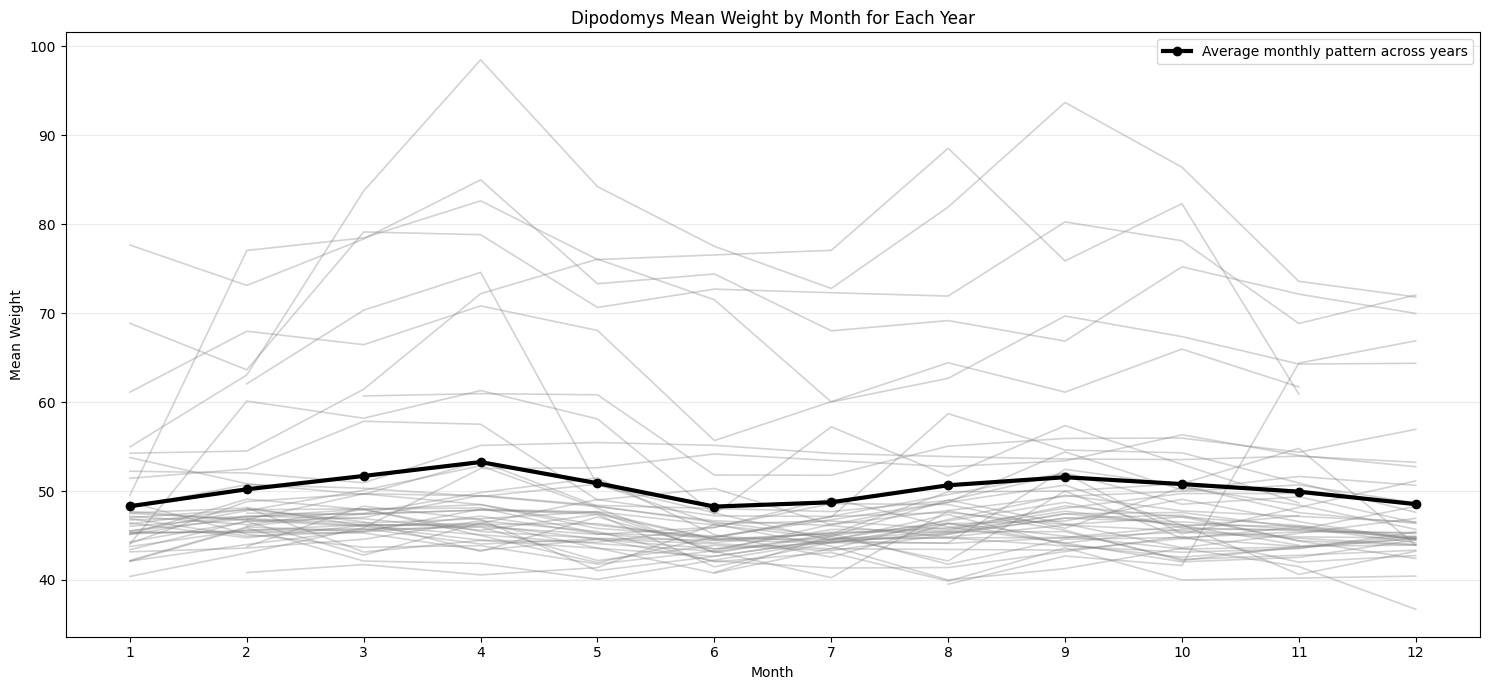

In [ ]:
# FIG 2.3

dipodomys_year_month_weight = dipodomys_monthly_df.dropna(subset=['mean_weight']).copy()

pivot_weight = dipodomys_year_month_weight.pivot(
    index='month',
    columns='year',
    values='mean_weight'
)

fig, ax = plt.subplots(figsize=(15, 7))

for year in pivot_weight.columns:
    yearly_values = pivot_weight[year].dropna()
    if len(yearly_values) >= 3:
        ax.plot(
            yearly_values.index,
            yearly_values.values,
            linewidth=1.2,
            alpha=0.35,
            color='gray'
        )

monthly_pattern = dipodomys_year_month_weight.groupby('month', as_index=False).agg(
    mean_weight=('mean_weight', 'mean')
)

ax.plot(
    monthly_pattern['month'],
    monthly_pattern['mean_weight'],
    linewidth=3,
    color='black',
    marker='o',
    label='Average monthly pattern across years'
)

ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Mean Weight')
ax.set_title('Dipodomys Mean Weight by Month for Each Year')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

This plot treats each year as its own month-by-month line. If many yearly lines rise and fall in similar months, that suggests a repeated seasonal pattern. If the gray yearly lines move in different directions from year to year, then the monthly changes may be more random or driven by year-specific conditions. The black line gives the average monthly pattern across all years, making it easier to see whether there is a repeated tendency underneath the yearly noise.

## Conclusion

- Monthly aggregation is better for seeing short-term variation and possible seasonal movement.
- Yearly aggregation is better for seeing the broader trend because it smooths over month-to-month changes.
- Looking at the full dataset gives the overall pattern, while the Dipodomys-only view gives a cleaner focused example with many data points.
- The Dipodomys month-within-year weight plot adds another layer by showing whether monthly weight trends repeat across years or change randomly from year to year.
- Hindfoot length is not used for that year-by-month seasonal plot because it is less likely to change meaningfully within one calendar year; weight is more useful for studying short-term monthly patterns.
- If the monthly scatter points stay close to the yearly line, yearly aggregation is probably enough. If the points spread widely around the line, or if the within-year lines show repeated seasonal movement, the monthly aggregation may be more useful.

# talk about seeds and p-hacking in sampling bias 